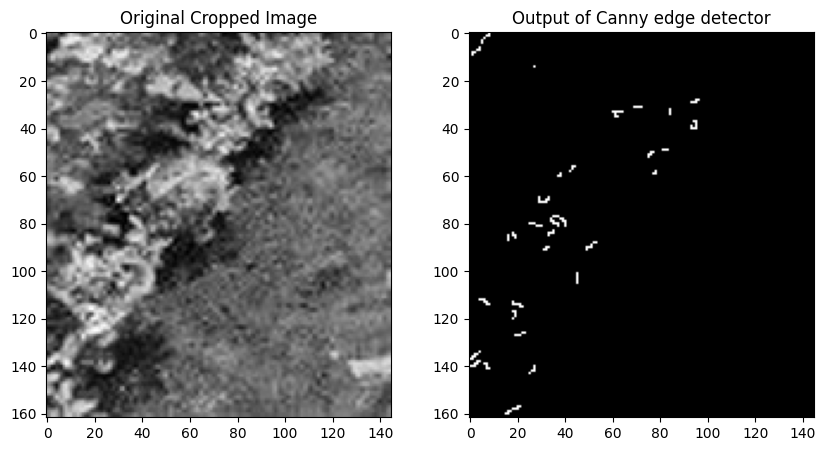

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
from sklearn.linear_model import RANSACRegressor

# 1. Load the cropped image in grayscale
img = cv.imread(r'C:\Users\kavin\Desktop\Assignmnet 2 pics\Picture3.jpg', cv.IMREAD_GRAYSCALE)

# Apply Canny edge detector with specified thresholds
edges = cv.Canny(img, 550, 690) # [cite: 14]

# Extract feature positions to x and y coordinates
indices = np.where(edges != 0) # [cite: 15]
x = indices[1] # [cite: 18]
y = indices[0] # [cite: 19]

# Note: In images, the y-axis is usually inverted (0 at the top). 
# You might want to invert y for standard mathematical plotting:
y = img.shape[0] - y 

# Plot original and edge image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Cropped Image')
ax[1].imshow(edges, cmap='gray')
ax[1].set_title('Output of Canny edge detector')
plt.show()

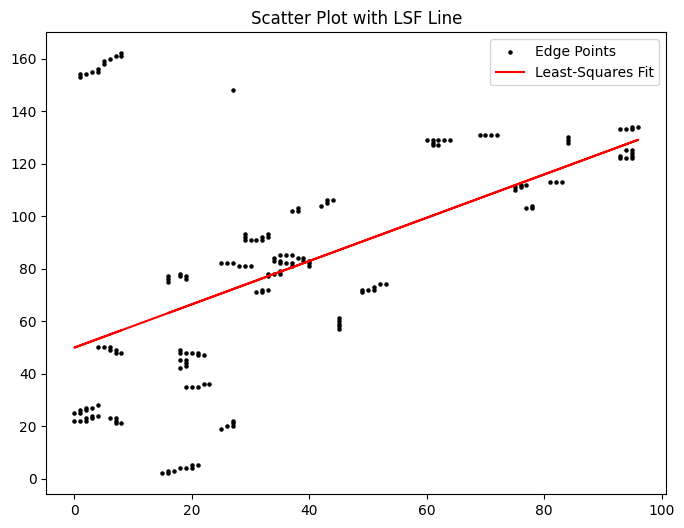

LSF Estimated Angle: 39.50 degrees


In [9]:
# 2. Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=5, c='black', label='Edge Points')

# 3. Least-Squares Fit (LSF)
# Fit a polynomial of degree 1 (a line: y = mx + c)
coefficients_lsf = np.polyfit(x, y, 1)
m_lsf, c_lsf = coefficients_lsf
y_lsf = m_lsf * x + c_lsf

plt.plot(x, y_lsf, color='red', label='Least-Squares Fit')
plt.title('Scatter Plot with LSF Line')
plt.legend()
plt.show()

# 4. Calculate Angle
angle_lsf_rad = np.arctan(m_lsf)
angle_lsf_deg = np.degrees(angle_lsf_rad)
print(f"LSF Estimated Angle: {angle_lsf_deg:.2f} degrees")